In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

# SFR

In [2]:
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from Query.STIRFutureOptions.STIRFutureOptionQuery import STIRFutureOptionQuery
from Query.STIRFutureOptions.STIRFutureOptionStructure import STIRFutureOptionStructure
from Query.STIRFutureOptions.STIRFutureOptionValue import STIRFutureOptionValue

from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

In [3]:
stirf_mdp = STIRFutureMDP(source="BARCHART_TOS_LIVE_STIRF-RL")
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")
# stirfo_mdp = STIRFutureOptionMDP(source="STIRFO_DUAL-QL")

In [5]:
as_of = datetime.date(2026, 3, 6)

q = STIRFutureOptionQuery(
    structure=STIRFutureOptionStructure.OUTRIGHT,
    value=STIRFutureOptionValue.PRICE,
    symbol="SFRZ27|5DP",  
    market_request={
        "endpoint": "option_snapshot",
        "timestamp": as_of,
        "use_ql_calculator": True,
        # "force_refresh": True,
    },
)

req = q.build_mdp_request(as_of)
pr = stirfo_mdp.get_pricer(req)

package, weights = q.resolve_package(pricer_or_curve=pr)
value_map = q.build_value_map(
    pricer_or_curve=pr,
    package=package,
    risk_weights=weights,
)

print("resolved_symbol:", package[0].symbol())
print("price:", value_map.apply(STIRFutureOptionValue.PRICE))
print("iv_normal_bps:", value_map.apply(STIRFutureOptionValue.IV_NORMAL_BPS))
print("delta:", value_map.apply(STIRFutureOptionValue.DELTA))
print("gamma:", value_map.apply(STIRFutureOptionValue.GAMMA))
print("vega:", value_map.apply(STIRFutureOptionValue.VEGA))
print("theta:", value_map.apply(STIRFutureOptionValue.THETA))

resolved_symbol: SFRZ27|9400P
price: 0.035
iv_normal_bps: 129.54643523032726
delta: -0.0482901507751661
gamma: 0.05736483557700766
vega: 0.13213657703609044
theta: -0.04694959034903194


In [23]:
smile = stirfo_mdp.fetch_sabr_smile(
    {
        "symbol": "SFRZ27",
        "as_of": as_of,
        # "force_refresh": True,
        "show_tqdm": True,
        # "strike_offsets_bps": "listed",
    }
)
smile

# # 
# smiles = stirfo_mdp.fetch_bulk_sabr_smile(
# 	{
# 		"symbols": ["SFRU27"],
# 		"timestamps": [
# 			datetime.date(2026, 2, 25),
# 			datetime.date(2026, 3, 6),
# 			# datetime.date(2026, 3, 5),
# 		],
# 		# "force_refresh": True,
# 		"show_tqdm": True,
# 	}
# )
# smiles

STIRFutureOptionSABRSmile(source='BARCHART_STIRFO-QL', symbol='SFRZ27', underlying_contract='SFRZ27', quote_timestamp=datetime.datetime(2026, 3, 6, 17, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))), params=STIRFutureOptionSABRParams(alpha=0.091801342561993, beta=0.5, rho=-0.06643154964680746, nu=0.6067187114841261, forward_price=96.82, forward_rate=3.180000000000007, time_to_expiry=1.7780821917808218, expiry_date=datetime.date(2027, 12, 15), as_of=datetime.date(2026, 3, 6)), points=(STIRFutureOptionSmilePoint(label='SFRZ27|5DC', right='C', delta_abs=4.752842482346846, atm_offset_bps=250.0, strike_price=94.375, strike_rate=5.625, iv_normal_price=1.2253441374290988, iv_normal_bps=122.53441374290988), STIRFutureOptionSmilePoint(label='SFRZ27|10DC', right='C', delta_abs=13.610636336175569, atm_offset_bps=150.0, strike_price=95.375, strike_rate=4.625, iv_normal_price=1.1000827688125403, iv_normal_bps=110.00827688125403), STIRFutureOptionSmilePoint(label='SFRZ27|15

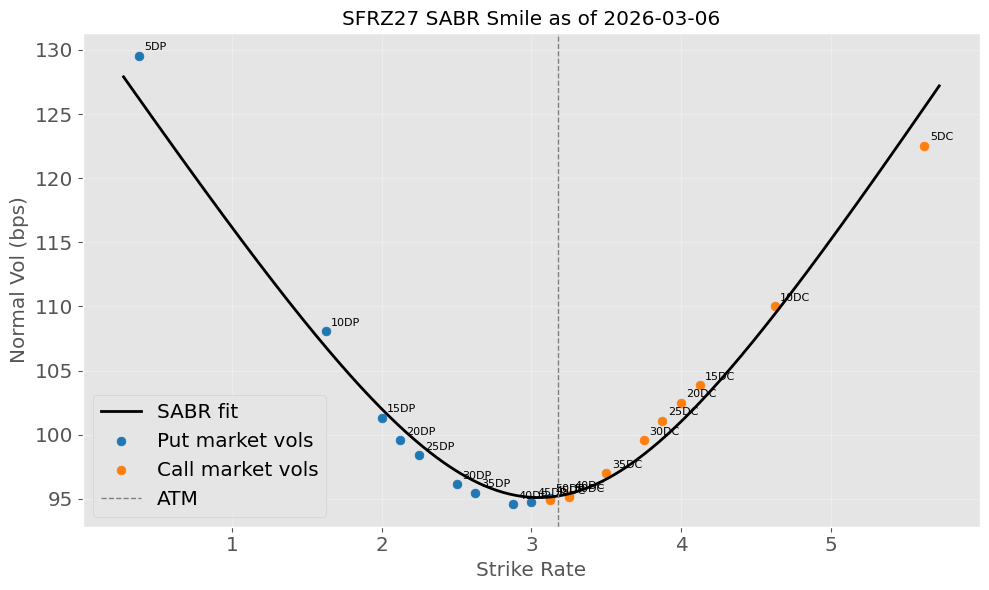

In [24]:
# smile = smiles["SFRU27"][datetime.date(2026, 2, 25)]

pts = sorted(smile.points, key=lambda p: p.strike_rate)
call_pts = [p for p in pts if p.right == "C"]
put_pts = [p for p in pts if p.right == "P"]

# Smooth strike grid in rate space
x_min = min(p.strike_rate for p in pts) - 0.10
x_max = max(p.strike_rate for p in pts) + 0.10
strike_grid = np.linspace(x_min, x_max, 400)

# Model vols from fitted SABR smile
sabr_vols_bps = smile.normal_vol(
    strike_grid,
    strike_space="rate",
    vol_units="bps",
)

fig, ax = plt.subplots(figsize=(10, 6))

# Smooth SABR curve
ax.plot(
    strike_grid,
    sabr_vols_bps,
    color="black",
    lw=2,
    label="SABR fit",
)

# Market vols
ax.scatter(
    [p.strike_rate for p in put_pts],
    [p.iv_normal_bps for p in put_pts],
    color="tab:blue",
    s=40,
    label="Put market vols",
)
ax.scatter(
    [p.strike_rate for p in call_pts],
    [p.iv_normal_bps for p in call_pts],
    color="tab:orange",
    s=40,
    label="Call market vols",
)

ax.axvline(
    smile.params.forward_rate,
    color="gray",
    ls="--",
    lw=1,
    label="ATM",
)

for p in pts:
    ax.annotate(
        p.label.split("|")[-1],
        (p.strike_rate, p.iv_normal_bps),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title(f"{smile.symbol} SABR Smile as of {smile.params.as_of}")
ax.set_xlabel("Strike Rate")
ax.set_ylabel("Normal Vol (bps)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


# USTS

In [2]:
from MDP.USTFutures.USTFutureOptionMDP import USTFutureOptionMDP
from MDP.USTFutures.USTFuturesMDP import USTFuturesMDP

In [3]:
ustf_mdp = USTFuturesMDP(source="BARCHART_USTF-RL")
ustfo_bc_mdp = USTFutureOptionMDP(source="BARCHART_USTFO-QL")
ustfo_qs_mdp = USTFutureOptionMDP(source="USTFO_DUAL-QL")

In [4]:
as_of = datetime.date(2026, 3, 6)

out = ustfo_bc_mdp.get_pricer({
    "endpoint": "option_snapshot",
    "symbols": ["TYM26|ATMS"],  
    "timestamp": as_of,
    "show_tqdm": True,
    "use_ql_calculator": True,
	# "force_refresh": True
})

pr = next(iter(out.values()))[0]
print("resolved_symbol:", pr.symbol())
print("price:", pr.price(), "iv_normal_bps:", pr.iv_normal_bps())
print("delta:", pr.delta(), "gamma:", pr.gamma(), "vega:", pr.vega(), "theta:", pr.theta())

resolved_symbol: ZNM26|1125S
price: 2.125 iv_normal_bps: 86.81949213671156
delta: -0.018436644925305667 gamma: 0.2949329841724009 vega: 0.3635149510538741 theta: -4.954960086169665


In [5]:
with ustfo_qs_mdp:
	smiles = ustfo_qs_mdp.fetch_bulk_sabr_smile(
		{
			"globex_symbols": ["TU_30", "FV_30", "TY_30", "TN_30", "US_30", "UL_30"],
			"timestamps": [
                datetime.date(2026, 2, 2),
            #     datetime.date(2026, 3, 3),
            #     datetime.date(2026, 3, 4),
            #     datetime.date(2026, 3, 5),
            #     datetime.date(2026, 3, 6),
            ],
	        "show_tqdm": True,
			# "force_refresh": True,
		}
	)
	# smiles_2 = ustfo_qs_mdp.fetch_bulk_sabr_smile(
	# 	{
	# 		"globex_symbols": ["TN_30", "US_30", "UL_30"],
	# 		"timestamps": [
    #             datetime.date(2026, 3, 5),
    #             datetime.date(2026, 3, 6),
    #         ],
	#         "show_tqdm": True,
	# 		# "force_refresh": True,
	# 	}
	# )

	# smile = ustfo_mdp.fetch_sabr_smile(
	# 	{
	# 		"globex_symbol": "TY_05",
	# 		"as_of": datetime.date(2026, 3, 4),
	# 	}
	# )

# smiles = smiles_1 | smiles_2
smiles

{'TU_30': {datetime.date(2026, 2, 2): USTFutureOptionSABRSmile(source='USTFO_DUAL-QL', globex_symbol='TU_30', underlying_contract='ZTH26', quote_timestamp=datetime.datetime(2026, 2, 2, 0, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))), fv01=0.0185963764697333, params=USTFutureOptionSABRParams(alpha=0.09487119265420876, beta=0.5, rho=0.40230965124363954, nu=3.152461899558813, forward_price=104.171875, forward_futures_ytm=3.5358581044294546, time_to_expiry=0.0821917808219178, expiry_date=datetime.date(2026, 3, 4), as_of=datetime.date(2026, 2, 2)), points=(USTFutureOptionSmilePoint(label='TU_30 5D Put', right='P', delta_abs=5.0, strike_price=103.65660820066714, strike_futures_ytm=3.8378342843211106, iv_normal_price=1.0926742488363026, iv_normal_bps=58.75737408385416), USTFutureOptionSmilePoint(label='TU_30 10D Put', right='P', delta_abs=10.0, strike_price=103.80429026872442, strike_futures_ytm=3.7510865935215727, iv_normal_price=1.0004771697193877, iv_normal_bps=

USTFutureOptionSABRParams(alpha=0.36843847182684314, beta=0.5, rho=0.155283997939332, nu=2.7219776145691936, forward_price=109.1875, forward_futures_ytm=3.674683133907343, time_to_expiry=0.0821917808219178, expiry_date=datetime.date(2026, 4, 5), as_of=datetime.date(2026, 3, 6))
forward price: 109.1875
forward futures ytm: 3.674683133907343
fv01: 0.042208705371824855


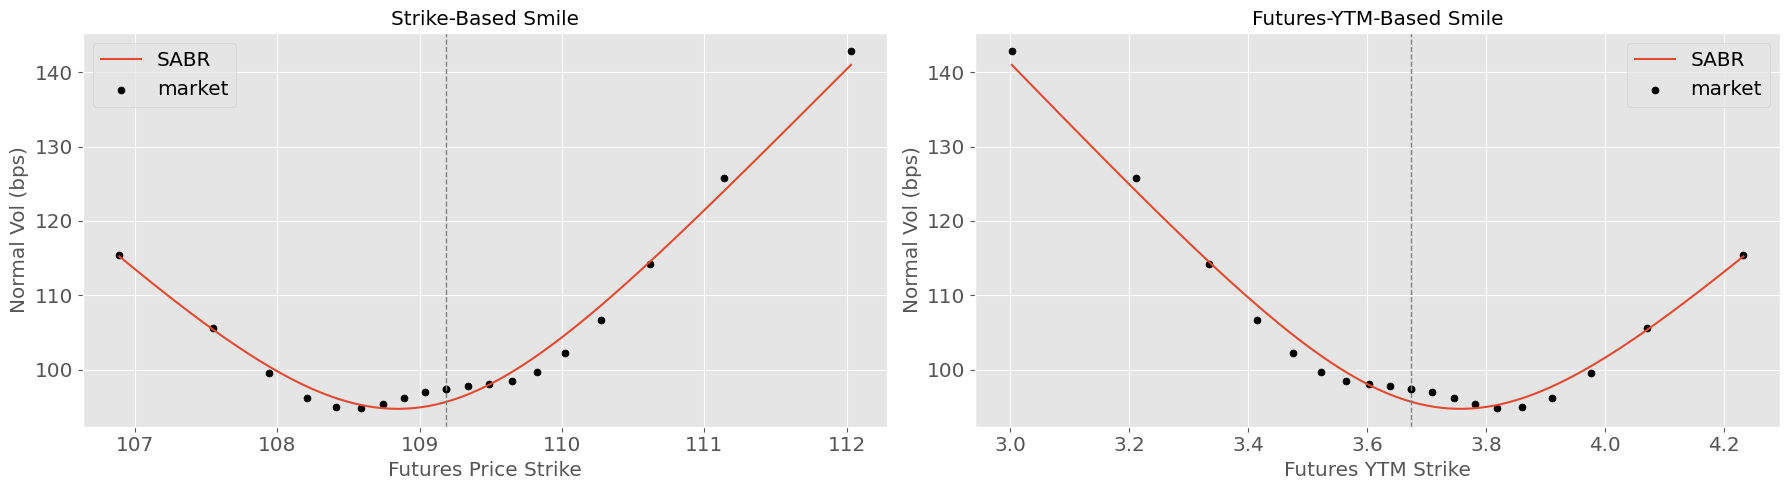

In [13]:
smile = smiles["FV_30"][datetime.date(2026, 3, 6)]
print(smile.params)
print("forward price:", smile.params.forward_price)
print("forward futures ytm:", smile.params.forward_futures_ytm)
print("fv01:", smile.fv01)

# strike-based grid
price_strikes = np.linspace(
    min(p.strike_price for p in smile.points),
    max(p.strike_price for p in smile.points),
    200,
)
price_vols_bps = smile.normal_vol(price_strikes, strike_space="price", vol_units="bps")

# YTM-based grid
ytm_strikes = np.linspace(
    min(p.strike_futures_ytm for p in smile.points),
    max(p.strike_futures_ytm for p in smile.points),
    200,
)
ytm_vols_bps = smile.normal_vol(ytm_strikes, strike_space="futures_ytm", vol_units="bps")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(price_strikes, price_vols_bps, label="SABR")
axes[0].scatter([p.strike_price for p in smile.points], [p.iv_normal_bps for p in smile.points], s=25, c="black", label="market")
axes[0].axvline(smile.params.forward_price, ls="--", lw=1, c="gray")
axes[0].set_title("Strike-Based Smile")
axes[0].set_xlabel("Futures Price Strike")
axes[0].set_ylabel("Normal Vol (bps)")
axes[0].legend()

axes[1].plot(ytm_strikes, ytm_vols_bps, label="SABR")
axes[1].scatter([p.strike_futures_ytm for p in smile.points], [p.iv_normal_bps for p in smile.points], s=25, c="black", label="market")
axes[1].axvline(smile.params.forward_futures_ytm, ls="--", lw=1, c="gray")
axes[1].set_title("Futures-YTM-Based Smile")
axes[1].set_xlabel("Futures YTM Strike")
axes[1].set_ylabel("Normal Vol (bps)")
axes[1].legend()

plt.tight_layout()
plt.show()
